In [1]:
import pandas as pd
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'pandas._libs.pandas_parser'

In [2]:
pip uninstall pandas

^C
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install pandas

In [17]:
UMCG = False

if UMCG:
    CITOR_preds_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial_32\LR_ensemble_preds.csv"
    ST_preds_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial32_singletox_models\all_ST_models_ens_predictions.csv"
    MT_preds_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial_32\ensemble_predictions.csv"
else:
    CITOR_preds_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial_32\LR_ensemble_preds_MDACC_no_UP.csv"
    ST_preds_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_May25\single_tox_models\all_ST_models_ens_predictions_MDACC_no_UP.csv"
    MT_preds_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_May25\Trial_32\ensemble_predictions_MDACC_no_UP.csv"


df_CITOR_preds = pd.read_csv(CITOR_preds_dir, sep=';')
df_ST_preds = pd.read_csv(ST_preds_dir, sep=';')
df_MT_preds = pd.read_csv(MT_preds_dir, sep=';')


In [18]:
%load_ext autoreload
%autoreload 2

from src.config_presets.tools.load_config import load_config
from src.visualization.calibration.adaptive_make_endpoint_plots import adaptive_make_endpoint_plots


config_path = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_May25\Trial_32\KFold1\DlModel_Config.yaml"
config = load_config(config_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_May25\Trial_32\KFold1\DlModel_Config.yaml


In [19]:
def seperate_preds_labels(df, endpoints):
    pred_columns = [col + '_pred' for col in endpoints]
    label_columns = [col + '_true' for col in endpoints]

    preds = df[pred_columns].values
    labels = df[label_columns].values

    # rename the columns in preds and labels by stripping '_pred' and '_true' from column names
    preds = pd.DataFrame(preds, columns=endpoints)
    labels = pd.DataFrame(labels, columns=endpoints)

    return preds, labels



In [20]:
endpoint_list = config['columns']['labels']

CITOR_preds, CITOR_labels = seperate_preds_labels(df_CITOR_preds, endpoint_list)
ST_preds, ST_labels = seperate_preds_labels(df_ST_preds, endpoint_list)
MT_preds, MT_labels = seperate_preds_labels(df_MT_preds, endpoint_list)

CITOR_dict = {"name" : "Reference",
              "preds" : CITOR_preds,
              "labels" : CITOR_labels}

ST_dict = {"name" : "ST",
                "preds" : ST_preds,
                "labels" : ST_labels}
MT_dict = {"name" : "MT",
                "preds" : MT_preds,
                "labels" : MT_labels}


In [21]:
from sklearn.metrics import roc_auc_score

for endpoint in endpoint_list:
    #print(CITOR_dict['labels'][endpoint])

    labels = CITOR_dict['labels'][endpoint]
    mask = labels != -1  # Create a mask for valid labels
    labels = labels[mask]
    preds = CITOR_dict['preds'][endpoint][mask]

    auc = roc_auc_score(labels, preds)
    print(f"CITOR AUC for {endpoint}: {auc:.3f}")

CITOR AUC for Aspiration_M06: 0.719
CITOR AUC for Dysphagia_M06: 0.668
CITOR AUC for Sticky_M06: 0.628
CITOR AUC for Taste_M06: 0.545
CITOR AUC for Xerostomia_M06: 0.603


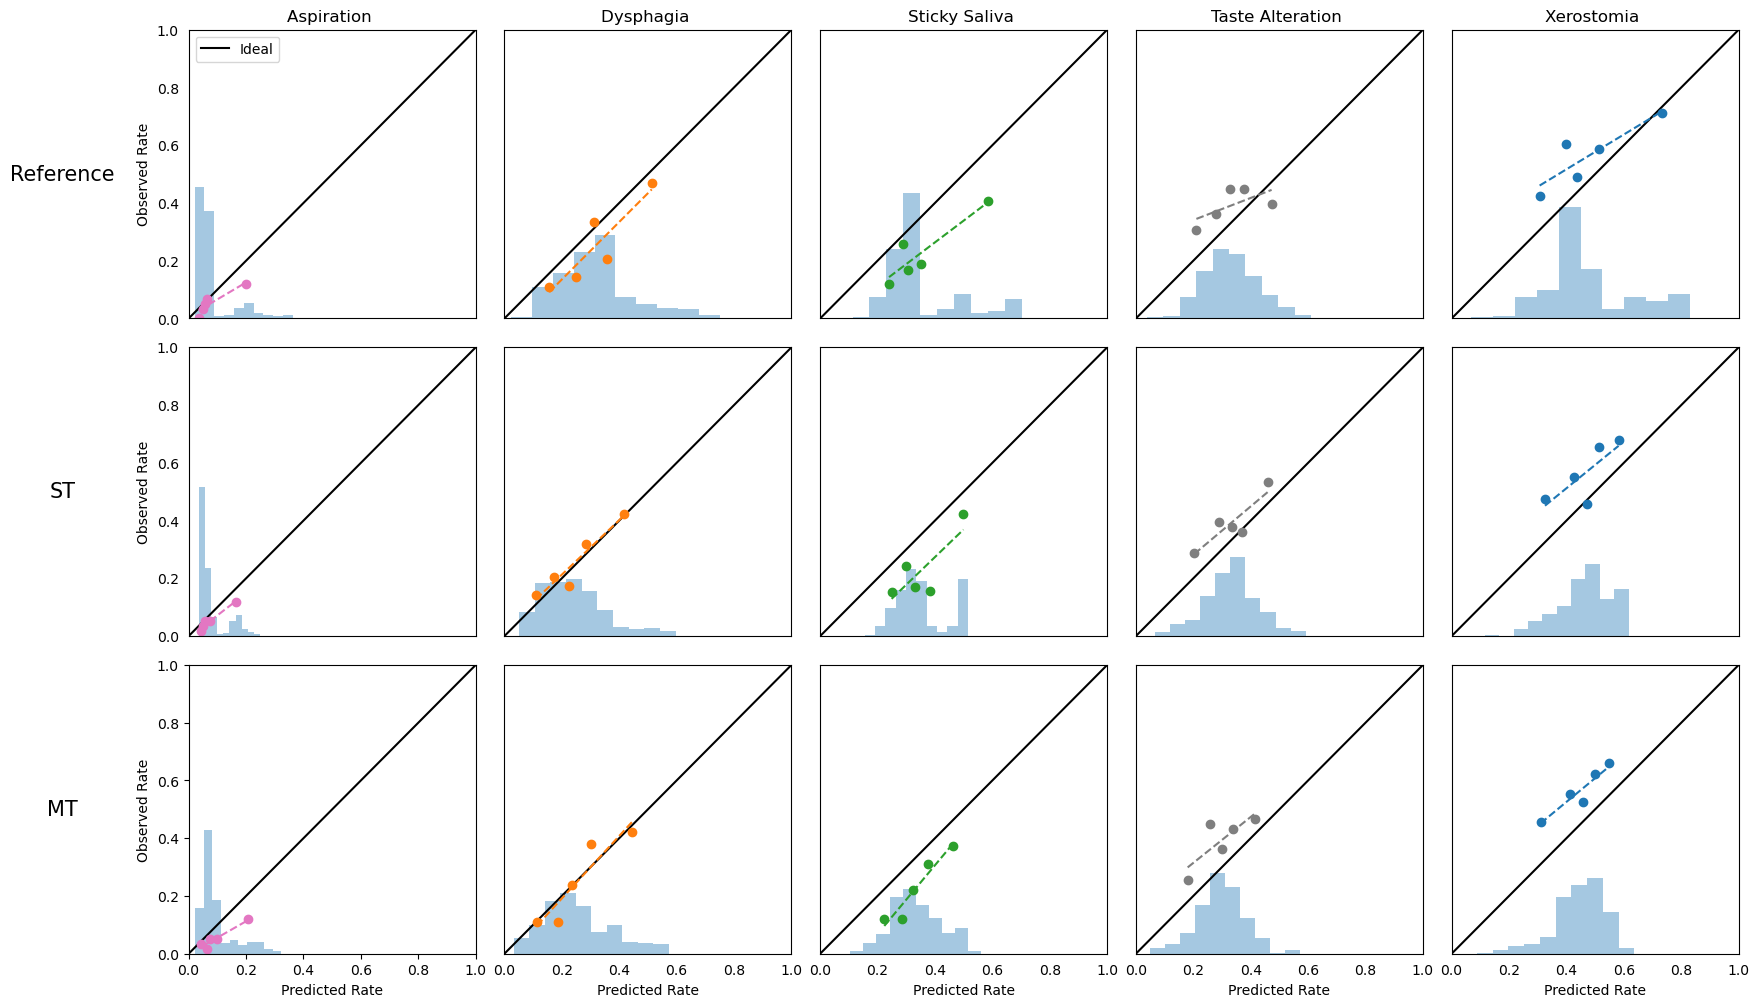

In [13]:
config['evaluation']['metrics']['calibration_bins'] = 5

fig = adaptive_make_calibration_plots(config=config, row_dicts=[CITOR_dict, ST_dict, MT_dict], column_names=endpoint_list, return_fig=True, filedir=None) # , save_dir=r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial_32\calibration_plots")

# Remove legends from all subplots except the first one
axes = fig.get_axes()
for i, ax in enumerate(axes):
    # Remove underscores in the column headers (subplot titles)
    title = ax.get_title()
    if title:
        title = title.replace('_M06', ' ')
        title = title.replace('Sticky', 'Sticky Saliva')
        title = title.replace('Taste', 'Taste Alteration')
        ax.set_title(title)

    legend = ax.get_legend()
    if legend is not None:
        if i == 0:
            continue
        legend.remove()

    

if UMCG:
    fig.savefig(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\0. Writing\figures\test_set_calibration_plots.png", dpi=600, bbox_inches='tight')
    fig.savefig(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\0. Writing\figures\test_set_calibration_plots.tiff", dpi=600, bbox_inches='tight')
else:
    fig.savefig(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\0. Writing\figures\MDACC_set_calibration_plots.png", dpi=600, bbox_inches='tight')
    fig.savefig(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\0. Writing\figures\MDACC_set_calibration_plots.tiff", dpi=600, bbox_inches='tight')


